In [10]:
import time

In [30]:
def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {'range': {ple_gui.scan_axis: in_range}}
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    #ple_gui._accumulated_data.mean(axis=0)
    #print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    #ple_gui.fit_result[1].params["center"].value
    return ple_gui.fit_result[1]

def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()

In [16]:
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

In [19]:
folder = r'Z:\Vlad\heavyIV\202-2-ARed\CPW\somewhere\B_rotation'

In [36]:
theta = 0
phi = 0 
tag = f"theta_{theta}_phi_{phi}_B_{0.2}_T"
save_ple(tag=tag,
            poi_name=None,
            folder_name=folder)

(5921.0, 7256.0)

In [31]:
fit = do_ple_scan(lines=1, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')

In [ ]:
delta = fit.params['center_2'].value - fit.params['center_1'].value
delta # in MHz

354.3233270394685

6748.180856237946

In [1]:
vector_magnet

<qudi.hardware.vector_magnet.ami_vector_magnet.Magnet3D(0x1f24c0495e0) at 0x000001F26CA5D040>

In [121]:
b = vector_magnet.get_field()

In [122]:
b

[1.601e-06, 0.200003165, -1.7088e-05]

In [4]:
magnetlogic

<qudi.logic.magnetlogic.MagnetLogic(0x1f24c049560) at 0x000001F25FA2FC40>

In [8]:
vector_magnet.ramp(field_target= [0.0, 0, 0.2])

In [37]:
# # Mapping SnV PLE Splitting vs. B-Field Orientation
#
# This notebook automates the process of mapping the photoluminescence excitation (PLE) 
# splitting of a single Tin-Vacancy (SnV) center as a function of an externally applied magnetic field's orientation.
#
#
# ## Experimental Plan
# 1.  **Define a spherical grid** for the magnetic field vector angles (`theta`, `phi`).
# 2.  **Iterate through each point** on this grid:
#     a. Convert the spherical coordinates (constant magnitude of 0.2 T, `theta`, `phi`) to Cartesian coordinates `[Bx, By, Bz]`.
#     b. **Ramp the vector magnet** to the target field vector.
#     c. **Perform a PLE scan** across the relevant optical transitions.
#     d. **Fit the PLE spectrum** to a model (e.g., a double Lorentzian) to find the center frequencies of the two peaks.
#     e. **Calculate the splitting** (`delta`) between the two peaks.
#     f. **Save the raw PLE data** to a file tagged with the B-field parameters.
#     g. **Store the calculated splitting** along with the angles in a results array.
# 3.  **Visualize the results**: After the sweep is complete, plot the recorded splitting `delta` as a function of `theta` and `phi` on a 2D polar projection (Hammer projection) to visualize the full map.

# ## 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from collections import namedtuple



In [ ]:
B_amplitude = 0.2  # Tesla

# Define the angular resolution of the sweep
theta_steps = 20  # Number of steps from 0 to 90 deg
phi_steps = 20   # Number of steps from 0 to 90 deg

# Create the grid of angles for the first octant (all components positive)
# theta: 0 to pi/2
# phi: 0 to p
thetas = np.linspace(0, np.pi/2, theta_steps)
phis = np.linspace(0, np.pi/2, phi_steps)

all_field_targets = []

# Iterate through each point on the spherical grid
for phi in phis:
    for theta in thetas:
        # a. Convert spherical to Cartesian coordinates
        Bx = B_amplitude * np.sin(theta) * np.cos(phi)
        By = B_amplitude * np.sin(theta) * np.sin(phi)
        Bz = B_amplitude * np.cos(theta)
        field_target = [Bx, By, Bz]
        all_field_targets.append(field_target)

print(f"Generated {len(all_field_targets)} points in the first octant.")

# ## 3. Prepare Data for Plotting
# Convert the list of points into a NumPy array for easier slicing
points_array = np.array(all_field_targets)


Generated 25 points in the first octant.


In [132]:
len(all_field_targets)

25

In [133]:
points_array = np.array(all_field_targets)

Generating 3D plot...


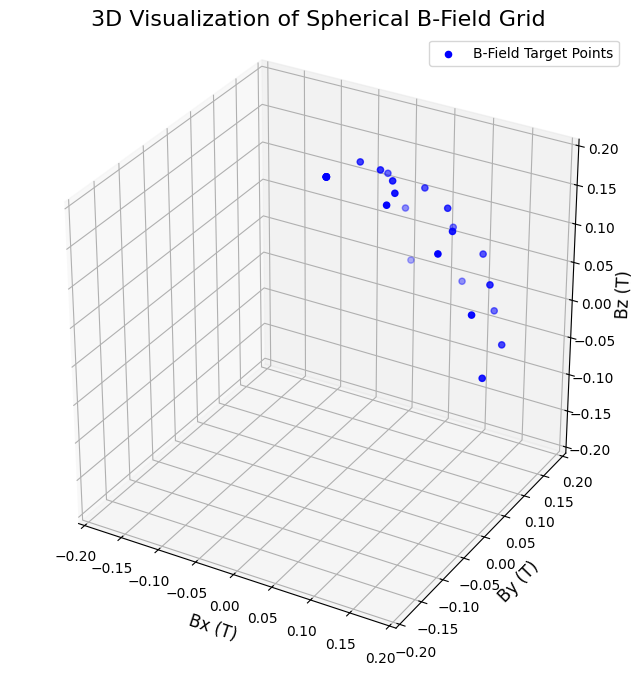

Plot displayed.


In [134]:
points_array = np.array(all_field_targets)

# Extract X, Y, and Z coordinates
x_coords = points_array[:, 0]
y_coords = points_array[:, 1]
z_coords = points_array[:, 2]

# ## 4. Create the 3D Plot
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o', label='B-Field Target Points')

# Add labels and a title for clarity
ax.set_xlabel('Bx (T)', fontsize=12)
ax.set_ylabel('By (T)', fontsize=12)
ax.set_zlabel('Bz (T)', fontsize=12)
ax.set_title('3D Visualization of Spherical B-Field Grid', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([-B_amplitude, B_amplitude])
ax.set_ylim([-B_amplitude, B_amplitude])
ax.set_zlim([-B_amplitude, B_amplitude])
ax.set_aspect('equal') # This is crucial for a correct aspect ratio

# Add a legend
ax.legend()

# Show the plot
plt.show()
print("Plot displayed.")

In [135]:
vector_magnet.ramp(field_target= field_target)

In [136]:
field_target

[1.2246467991473533e-17, 0.2, 1.2246467991473533e-17]

In [ ]:
list(vector_magnet.get_ramping_state()) == [2, 2, 2]

True

In [140]:
vector_magnet.get_ramping_state()

[2, 2, 2]

In [141]:
ple_gui._fit_averaged = True

In [142]:
folder = r'Z:\Vlad\heavyIV\202-2-ARed\CPW\somewhere\B_sweep'

In [ ]:
while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        time.sleep(2)
ple_splitting = []
for field_target in all_field_targets:
    print(f"Ramping to field target: {field_target}")
    vector_magnet.ramp(field_target= field_target)
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        time.sleep(2)
    fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
    while laser_scanner_logic.module_state() == 'locked':
        time.sleep(0.5)
    delta = fit.params['center_2'].value - fit.params['center_1'].value
  
    tag = f"target_{field_target}_T"
    save_ple(tag=tag,
                poi_name=None,
                folder_name=folder)
    ple_splitting.append(delta) # in MHz

In [ ]:
import time
from tqdm.auto import tqdm # Import tqdm for progress bars

In [ ]:
print("Waiting for initial vector magnet ramping to complete...")
while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
    print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
    time.sleep(2)
print("✅ Vector magnet is ready.")

ple_splitting = []

# --- Main Loop with tqdm Progress Bar ---
# Use tqdm to create a progress bar for the loop over field targets
for field_target in tqdm(all_field_targets, desc="Field Target Progress"):
    print(f"\n--- Starting new measurement for target: {field_target} ---")
    
    # --- Ramping the Field ---
    print(f"Ramping to field target: {field_target} T")
    vector_magnet.ramp(field_target=field_target)
    
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"🌀 Waiting for magnet... Current state: {vector_magnet.get_ramping_state()}")
        time.sleep(2)
    print("✅ Field ramp complete.")
    
    # --- Performing PLE Scan ---
    print("🔬 Starting PLE scan...")
    fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
    print("✅ PLE scan finished. Fit parameters obtained.")

    # --- Waiting for Laser Scanner ---
    while laser_scanner_logic.module_state() == 'locked':
        print("⏳ Waiting for laser scanner module to unlock...")
        time.sleep(0.5)
    print("✅ Laser scanner is unlocked.")

    # --- Calculating Splitting ---
    delta = fit.params['center_2'].value - fit.params['center_1'].value
    print(f"📊 Calculated PLE splitting (delta): {delta:.2f} MHz")
    ple_splitting.append(delta)

    # --- Saving Data ---
    tag = f"target_{field_target}_T"
    print(f"💾 Saving data with tag: '{tag}' to folder: '{folder}'")
    save_ple(tag=tag,
             poi_name=None,
             folder_name=folder)
    print("✅ Data saved successfully.")

print("\n--- All measurements complete! ---")
print(f"Final PLE Splitting Values (MHz): {ple_splitting}")